# Interpolate venue home-origin activity to census ADAs

The venue home-origin data (`data/activity/venues_homes.csv`) reports `unique_devices`
per **geohash6** cell, per venue, per `time_period`. Geohash cells don't line up
with any meaningful administrative boundary, so this notebook reallocates that
activity onto **ADAs** (aggregate dissemination areas — a Census Toronto
sub-neighbourhood-level unit) using **population-weighted areal interpolation**:
each geohash cell's activity is split across the ADAs it overlaps, in proportion
to (overlap area × ADA population density) — i.e. assuming residents are
uniformly distributed within an ADA, so the more populated part of the overlap
gets the larger share.

Output: one compact JSON file per venue under `static/venue_home_origin/`, each
holding, for every ADA and every `time_period` (`all`, `evening`, `nine-five`,
`weekdays`, `weekends`), that ADA's **% share of the venue's total interpolated
home-origin activity** for that time period (shares sum to ~100% across all
ADAs). Percent-of-total is used instead of raw/absolute counts because the
underlying mobility data license prohibits publishing raw counts — this matches
how `venue_stops.csv` / `venues_homes.csv` already express things as proportions.

No new geometry is written: the 279 ADA polygons are identical for every venue
(unlike the per-venue commute-time isochrones), so duplicating them into 85
separate PMTiles would be wasteful. The front end instead joins each venue's
small JSON to the ADA polygons already loaded from
`src/data/toronto-ada-wide.geo.json` by `ADAUID`.


In [1]:
import json
from pathlib import Path

import geohash
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import box
from shapely.ops import unary_union
from tqdm.notebook import tqdm


In [2]:
# --- Paths ---
DATA_DIR = Path("../../data")
ACTIVITY_DIR = DATA_DIR / "activity"
CENSUS_DIR = DATA_DIR / "census"

VENUES_HOMES_CSV = ACTIVITY_DIR / "venues_homes.csv"
ADA_WIDE_GPKG = CENSUS_DIR / "ada-wide" / "toronto-ada-wide.gpkg"  # ADA geometry + pop_2021_count, pre-joined

STATIC_DIR = Path("../../static")
OUTPUT_DIR = STATIC_DIR / "venue_home_origin"

# --- Parameters ---
TIME_PERIODS = ["all", "evening", "nine-five", "weekdays", "weekends"]

ADA_CRS = "EPSG:3347"  # StatCan Lambert projection the ADA polygons ship in — metres, good for area math

# A geohash cell whose bounding box overlaps less than this fraction of its own
# area with the modeled ADAs is treated as "outside the study area" and dropped,
# rather than force-allocating its whole value to a sliver overlap (see below).
MIN_OVERLAP_FRAC = 0.01

ROUND_DECIMALS = 4  # precision for the published % share values

# --- Chart styling (see dataviz skill: fixed categorical order, single-hue sequential) ---
CATEGORICAL_PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
]
CHART_GRID_COLOR = "#e1e0d9"
CHART_MUTED_TEXT = "#898781"


def style_axis(ax):
    """Shared cosmetic cleanup: recessive grid, no top/right spines."""
    ax.grid(axis="y", color=CHART_GRID_COLOR, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.tick_params(colors=CHART_MUTED_TEXT)


## Load base data

`toronto-ada-wide.gpkg` already has ADA geometry and `pop_2021_count` joined
(279 ADAs, no missing population values), so no separate census join is needed.


In [3]:
ada = gpd.read_file(ADA_WIDE_GPKG)[["ADAUID", "pop_2021_count", "geometry"]].to_crs(ADA_CRS)
homes = pd.read_csv(VENUES_HOMES_CSV)

venue_ids = sorted(homes.venue_id.unique())
venue_names = homes[["venue_id", "venue_name"]].drop_duplicates().set_index("venue_id")["venue_name"].to_dict()

print(f"{len(ada)} ADAs (pop range {ada.pop_2021_count.min():.0f}-{ada.pop_2021_count.max():.0f})")
print(f"{len(homes)} home-origin rows, {len(venue_ids)} venues, {homes.home_geohash6.nunique()} unique geohash6 cells")
print("time_period breakdown:")
print(homes.time_period.value_counts())


279 ADAs (pop range 2377-25729)
44642 home-origin rows, 85 venues, 1182 unique geohash6 cells
time_period breakdown:
time_period
all          13277
weekdays     11094
nine-five     6925
evening       6885
weekends      6461
Name: count, dtype: int64


## Build geohash cell polygons

Geohash6 codes are decoded to their true (unrounded) bounding box using
`decode_exactly`, giving a rectangular cell polygon in lat/lon, then reprojected
to the ADA polygons' CRS so overlap areas are computed in metres, not degrees.
This only needs to be done once per unique geohash (1,182 cells total), not once
per venue.


In [4]:
def geohash_bbox(gh):
    lat, lon, lat_err, lon_err = geohash.decode_exactly(gh)
    return box(lon - lon_err, lat - lat_err, lon + lon_err, lat + lat_err)


unique_geohashes = homes.home_geohash6.unique()
geohash_geoms = [geohash_bbox(gh) for gh in tqdm(unique_geohashes, desc="decoding geohash cells")]

geohash_gdf = gpd.GeoDataFrame(
    {"geohash": unique_geohashes}, geometry=geohash_geoms, crs="EPSG:4326"
).to_crs(ADA_CRS)
geohash_gdf["cell_area"] = geohash_gdf.geometry.area


decoding geohash cells:   0%|          | 0/1182 [00:00<?, ?it/s]

## Population-weighted areal interpolation: geohash → ADA weights

For each geohash cell that overlaps one or more ADAs, split its value across
those ADAs in proportion to `overlap_area × ADA_population_density` (population
density assumed uniform within each ADA — the finest resolution the Census data
gives us). Weights are normalized to sum to 1 across the ADAs a given geohash
overlaps.

This mapping only depends on geohash geometry, not on venue or time period, so
it's computed **once** and reused for every venue/time_period combination below.

A geohash cell that only marginally clips an ADA polygon at its edge (e.g. a
sliver from touching, not truly being inside the study area) would otherwise get
100% of its value force-allocated to that sliver once weights are normalized to
sum to 1. To avoid that artifact, any geohash whose *total* overlap with the
combined ADA footprint is under `MIN_OVERLAP_FRAC` of its own area is dropped
entirely — its activity is treated as being outside the modeled area rather than
assigned somewhere spurious.


In [5]:
# --- Drop geohash cells with negligible overlap with the modeled ADA footprint ---
ada_union = unary_union(ada.geometry.values)
geohash_gdf["overlap_frac"] = geohash_gdf.geometry.intersection(ada_union).area / geohash_gdf["cell_area"]

n_dropped = (geohash_gdf["overlap_frac"] < MIN_OVERLAP_FRAC).sum()
print(f"Dropping {n_dropped} / {len(geohash_gdf)} geohash cells with <{MIN_OVERLAP_FRAC:.0%} overlap with the ADA footprint")

geohash_gdf_kept = geohash_gdf[geohash_gdf["overlap_frac"] >= MIN_OVERLAP_FRAC].copy()

# --- Overlay kept geohash cells against ADAs to get every (geohash, ADA) intersection piece ---
ada_area = ada.set_index("ADAUID").geometry.area  # m^2, denominator for population density

overlay = gpd.overlay(
    geohash_gdf_kept[["geohash", "geometry"]],
    ada[["ADAUID", "pop_2021_count", "geometry"]],
    how="intersection",
    keep_geom_type=False,
)
overlay["overlap_area"] = overlay.geometry.area
overlay = overlay[overlay["overlap_area"] > 0]  # drop degenerate point/line touches

overlay["ada_area"] = overlay["ADAUID"].map(ada_area)
overlay["pop_density"] = overlay["pop_2021_count"] / overlay["ada_area"]
overlay["weight_raw"] = overlay["overlap_area"] * overlay["pop_density"]

# Normalize to sum to 1 across the ADAs each geohash cell overlaps
weight_totals = overlay.groupby("geohash")["weight_raw"].transform("sum")
overlay["weight"] = overlay["weight_raw"] / weight_totals

geohash_ada_weights = overlay[["geohash", "ADAUID", "weight"]].reset_index(drop=True)
print(f"{len(geohash_ada_weights)} (geohash, ADA) weight pairs across {geohash_ada_weights.geohash.nunique()} geohash cells")


Dropping 6 / 1182 geohash cells with <1% overlap with the ADA footprint


2913 (geohash, ADA) weight pairs across 1176 geohash cells


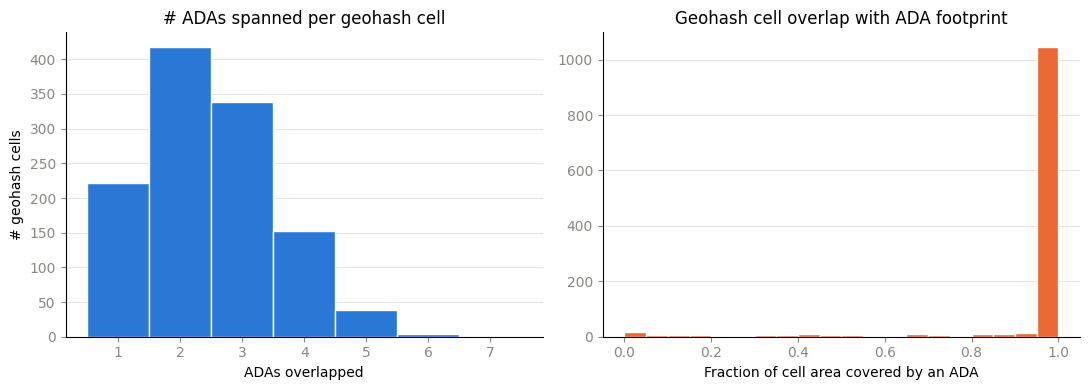

In [6]:
# Summary charts: how much interpolation is actually happening, and where activity falls outside the study area
adas_per_geohash = geohash_ada_weights.groupby("geohash").size()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

max_adas = adas_per_geohash.max()
axes[0].hist(
    adas_per_geohash, bins=range(1, max_adas + 2), align="left", color=CATEGORICAL_PALETTE[0], edgecolor="white"
)
axes[0].set_title("# ADAs spanned per geohash cell")
axes[0].set_xlabel("ADAs overlapped")
axes[0].set_ylabel("# geohash cells")
axes[0].set_xticks(range(1, max_adas + 1))
style_axis(axes[0])

axes[1].hist(geohash_gdf["overlap_frac"], bins=20, color=CATEGORICAL_PALETTE[1], edgecolor="white")
axes[1].set_title("Geohash cell overlap with ADA footprint")
axes[1].set_xlabel("Fraction of cell area covered by an ADA")
style_axis(axes[1])

plt.tight_layout()
plt.show()


## Interpolate estimated activity per venue × time_period

Join `unique_devices` (chosen because we want *where people are travelling from*,
not raw ping counts) against the geohash → ADA weight table, allocate, then sum
by venue/time_period/ADA to get each ADA's **estimated** interpolated activity.
Finally convert to a **% share of that venue+time_period's total** — the number
actually published, since raw/absolute figures cannot be released.


In [7]:
homes_weighted = homes.merge(geohash_ada_weights, left_on="home_geohash6", right_on="geohash", how="inner")
homes_weighted["allocated_devices"] = homes_weighted["unique_devices"] * homes_weighted["weight"]

allocated = (
    homes_weighted.groupby(["venue_id", "time_period", "ADAUID"])["allocated_devices"]
    .sum()
    .reset_index()
)

# % share of each venue+time_period's total interpolated activity — the published metric
venue_period_totals = allocated.groupby(["venue_id", "time_period"])["allocated_devices"].transform("sum")
allocated["pct_share"] = allocated["allocated_devices"] / venue_period_totals * 100

# Diagnostic only (not published): how much of each venue/time_period's raw activity
# actually fell inside the modeled ADA footprint and could be interpolated at all
raw_totals = homes.groupby(["venue_id", "time_period"])["unique_devices"].sum().rename("raw_total")
alloc_totals = allocated.groupby(["venue_id", "time_period"])["allocated_devices"].sum().rename("allocated_total")
coverage = pd.concat([raw_totals, alloc_totals], axis=1).reset_index()
coverage["coverage_pct"] = coverage["allocated_total"] / coverage["raw_total"] * 100

print(coverage["coverage_pct"].describe())


count    421.000000
mean      99.929232
std        0.343227
min       95.945946
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: coverage_pct, dtype: float64


In [8]:
# Sanity check: every venue x time_period combination present in the raw data should
# have made it into `allocated` with at least some coverage
expected_combos = homes[["venue_id", "time_period"]].drop_duplicates()
missing = expected_combos.merge(
    coverage[["venue_id", "time_period"]], on=["venue_id", "time_period"], how="left", indicator=True
).query("_merge == 'left_only'")
print(f"{len(missing)} venue/time_period combos with zero interpolated coverage (will be published as all-zero)")
if len(missing):
    print(missing[["venue_id", "time_period"]].to_string(index=False))


0 venue/time_period combos with zero interpolated coverage (will be published as all-zero)


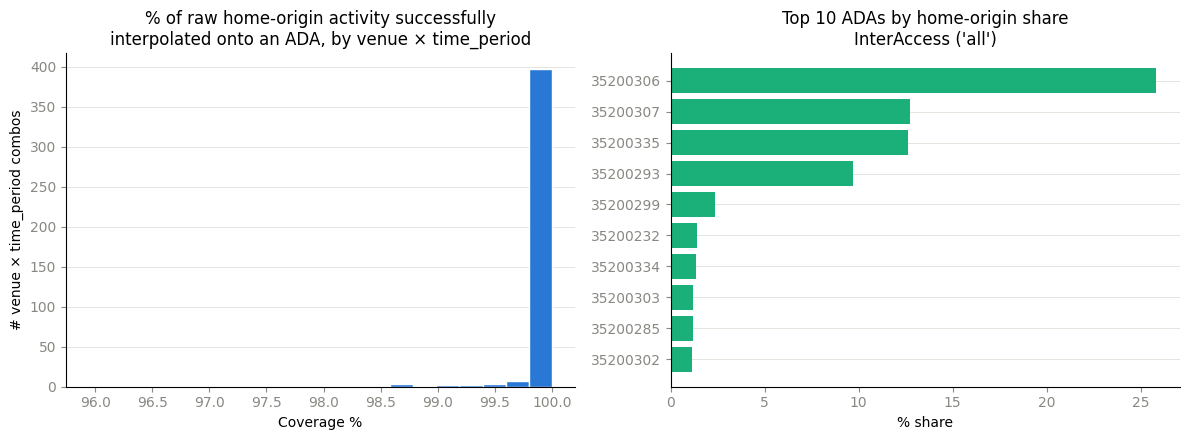

In [9]:
# Summary chart: coverage distribution, and one example venue's top ADAs
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(coverage["coverage_pct"], bins=20, color=CATEGORICAL_PALETTE[0], edgecolor="white")
axes[0].set_title("% of raw home-origin activity successfully\ninterpolated onto an ADA, by venue × time_period")
axes[0].set_xlabel("Coverage %")
axes[0].set_ylabel("# venue × time_period combos")
style_axis(axes[0])

# Example: first venue's "all" time_period, top 10 ADAs by share
example_venue_id = venue_ids[0]
example = (
    allocated[(allocated.venue_id == example_venue_id) & (allocated.time_period == "all")]
    .nlargest(10, "pct_share")
    .sort_values("pct_share")
)
axes[1].barh(example["ADAUID"].astype(str), example["pct_share"], color=CATEGORICAL_PALETTE[2])
axes[1].set_title(f"Top 10 ADAs by home-origin share\n{venue_names[example_venue_id]} ('all')")
axes[1].set_xlabel("% share")
style_axis(axes[1])

plt.tight_layout()
plt.show()


## Assemble & write per-venue JSON files

One file per venue: `static/venue_home_origin/venue_<id>.json`, mapping every
ADA (all 279, zero-filled where a venue has no interpolated activity there) to
its `{all, evening, nine-five, weekdays, weekends}` % shares. Written
**pretty-printed** (`indent=2`) rather than as a single-line blob — these files
are small enough (~25KB/venue) that human-readability is worth the extra
whitespace.


In [10]:
all_ada_ids = sorted(ada["ADAUID"].tolist())

pivot = allocated.pivot_table(
    index=["venue_id", "ADAUID"], columns="time_period", values="pct_share", fill_value=0.0
).reindex(columns=TIME_PERIODS, fill_value=0.0)

venue_records = {}
for venue_id, venue_group in tqdm(pivot.groupby(level="venue_id"), desc="assembling per-venue records"):
    venue_group = venue_group.droplevel("venue_id").reindex(all_ada_ids, fill_value=0.0)
    venue_records[int(venue_id)] = venue_group.round(ROUND_DECIMALS).to_dict(orient="index")

# Venues with zero coverage entirely (see sanity check above) still get a full,
# all-zero record so every venue in the dataset has a file
zero_record = {ada_id: dict.fromkeys(TIME_PERIODS, 0.0) for ada_id in all_ada_ids}
for venue_id in venue_ids:
    venue_records.setdefault(venue_id, zero_record)

print(f"{len(venue_records)} venue records assembled, {len(all_ada_ids)} ADAs each")


assembling per-venue records:   0%|          | 0/85 [00:00<?, ?it/s]

85 venue records assembled, 279 ADAs each


In [11]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for venue_id, record in tqdm(venue_records.items(), desc="writing per-venue JSON files"):
    out_path = OUTPUT_DIR / f"venue_{venue_id}.json"
    with open(out_path, "w") as f:
        json.dump(record, f, indent=2)

file_sizes = [(OUTPUT_DIR / f"venue_{vid}.json").stat().st_size for vid in venue_records]
print(
    f"Wrote {len(file_sizes)} files to {OUTPUT_DIR.resolve()}: "
    f"{sum(file_sizes) / 1024:.1f} KB total, {sum(file_sizes) / len(file_sizes):.0f} bytes/file avg"
)


writing per-venue JSON files:   0%|          | 0/85 [00:00<?, ?it/s]

Wrote 85 files to /home/aniket/Programming/eddit-tac/static/venue_home_origin: 2917.5 KB total, 35148 bytes/file avg


In [12]:
# Sanity check: preview one venue's file, and confirm shares sum to ~100% per time_period
example_path = OUTPUT_DIR / f"venue_{example_venue_id}.json"
example_record = json.load(open(example_path))

print(f"{example_path.name} — {venue_names[example_venue_id]}")
print(json.dumps(dict(list(example_record.items())[:3]), indent=2))

sums = {
    tp: round(sum(v[tp] for v in example_record.values()), 2) for tp in TIME_PERIODS
}
print("\n% share sums per time_period (should be ~100, or 0 if that period had no coverage):")
print(sums)


venue_1.json — InterAccess
{
  "35200001": {
    "all": 0.0539,
    "evening": 0.0,
    "nine-five": 0.0,
    "weekdays": 0.0,
    "weekends": 0.1632
  },
  "35200002": {
    "all": 0.0391,
    "evening": 0.004,
    "nine-five": 0.0101,
    "weekdays": 0.0053,
    "weekends": 0.1089
  },
  "35200003": {
    "all": 0.0,
    "evening": 0.0,
    "nine-five": 0.0,
    "weekdays": 0.0,
    "weekends": 0.0
  }
}

% share sums per time_period (should be ~100, or 0 if that period had no coverage):
{'all': 100.0, 'evening': 100.0, 'nine-five': 100.0, 'weekdays': 100.0, 'weekends': 100.0}


## Front-end legend breakpoints (quintiles)

The map's demography layers each use a fixed 5-color step scale with
hand-picked breakpoints (`src/lib/maps/tacLayerConfig.js`). To match that same
look for the new activity layers, this computes **quintile breakpoints (20th /
40th / 60th / 80th percentile)** for each `time_period`, pooling every nonzero
% share value across all 85 venues × 279 ADAs.

Zero-share ADAs are excluded from the quintile calculation on purpose: for any
given venue, most ADAs draw zero visitors, so including all those zeros would
collapse the low breakpoints to ~0 and make the scale useless. On the map,
zero/no-data ADAs are instead rendered in the same neutral gray demography
already uses for missing data — the 5-color ramp is reserved for ADAs that
actually contributed some visitors.


In [13]:
QUINTILE_PERCENTILES = [20, 40, 60, 80]

legend_breaks = {}
for period in TIME_PERIODS:
    nonzero = allocated.loc[allocated.time_period == period, "pct_share"]
    nonzero = nonzero[nonzero > 0]
    legend_breaks[period] = [round(v, 3) for v in np.percentile(nonzero, QUINTILE_PERCENTILES)]

print("Quintile breakpoints per time_period (% share, nonzero only):")
for period, breaks in legend_breaks.items():
    print(f"  {period:>10}: {breaks}")

print("\nReady to paste into tacLayerConfig.js:\n")
print(json.dumps(legend_breaks, indent=4))


Quintile breakpoints per time_period (% share, nonzero only):
         all: [np.float64(0.042), np.float64(0.106), np.float64(0.221), np.float64(0.565)]
     evening: [np.float64(0.044), np.float64(0.123), np.float64(0.293), np.float64(0.82)]
   nine-five: [np.float64(0.052), np.float64(0.146), np.float64(0.333), np.float64(0.938)]
    weekdays: [np.float64(0.043), np.float64(0.11), np.float64(0.235), np.float64(0.638)]
    weekends: [np.float64(0.051), np.float64(0.145), np.float64(0.33), np.float64(0.914)]

Ready to paste into tacLayerConfig.js:

{
    "all": [
        0.042,
        0.106,
        0.221,
        0.565
    ],
    "evening": [
        0.044,
        0.123,
        0.293,
        0.82
    ],
    "nine-five": [
        0.052,
        0.146,
        0.333,
        0.938
    ],
    "weekdays": [
        0.043,
        0.11,
        0.235,
        0.638
    ],
    "weekends": [
        0.051,
        0.145,
        0.33,
        0.914
    ]
}
